<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/GP2__2_BoW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd


In [37]:
url = "https://raw.githubusercontent.com/latifahaljurayyan/insightApp/refs/heads/main/dataset_reviews.csv"
df = pd.read_csv(url)
print(df.shape)

(47525, 4)


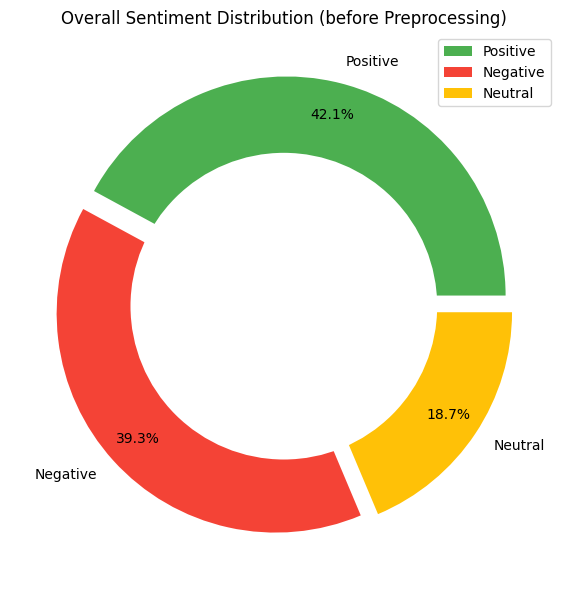

In [38]:
import matplotlib.pyplot as plt


sentiment_counts = df["sentiment_label"].value_counts()

sizes = sentiment_counts.values
labels = sentiment_counts.index


color_map = {
    "Positive": "#4CAF50",
    "Negative": "#F44336",
    "Neutral": "#FFC107"
}


colors = [color_map[label] for label in labels]

explode = [0.05] * len(labels)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Sentiment Distribution (before Preprocessing)")

plt.legend(labels, loc="upper right")

plt.tight_layout()
plt.show()

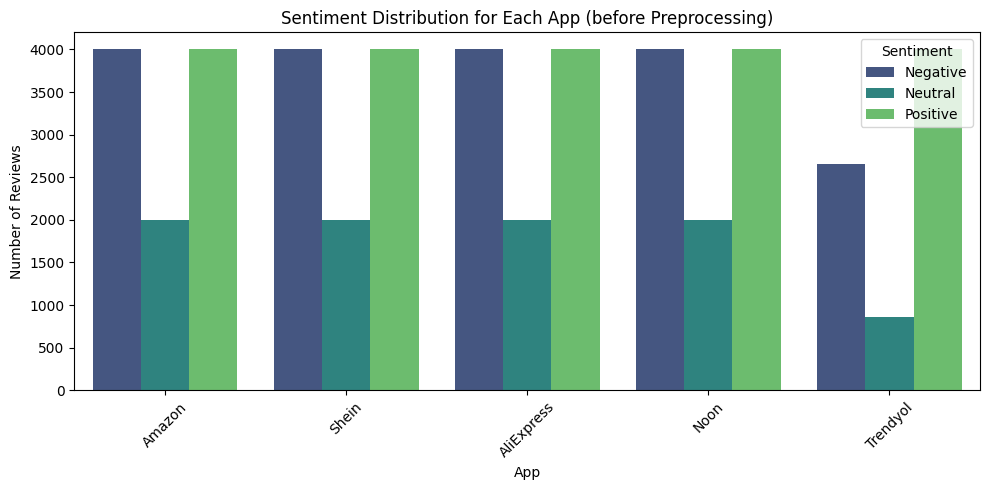

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (before Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [40]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    20000
Negative    18659
Neutral      8866
Name: count, dtype: int64


In [41]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 45101


In [42]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [43]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,no way to talk to someone about fake charges,no way to talk to someone about fake charges
1,stop harassing me to join prime ! i don't want...,stop harassing me to join prime i dont want it
2,What's with no longer seeing the map when trac...,whats with no longer seeing the map when track...
3,"Unable to cancel free Prime trial! Oh, I can f...",unable to cancel free prime trial oh i can fol...
4,might just cancel Amazon after this experience...,might just cancel amazon after this experience...
5,I don't know how they could make this app any ...,i dont know how they could make this app any w...
6,terrible idea,terrible idea
7,STICK TO LOCAL SHOPPING BEFORE YOU BET ANYTHIN...,stick to local shopping before you bet anythin...
8,Since the AI takes a role. Some problems canno...,since the ai takes a role some problems cannot...
9,not working properly,not working properly


In [44]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [45]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,no way to talk to someone about fake charges,"[no, way, to, talk, to, someone, about, fake, ..."
1,stop harassing me to join prime i dont want it,"[stop, harassing, me, to, join, prime, i, dont..."
2,whats with no longer seeing the map when track...,"[whats, with, no, longer, seeing, the, map, wh..."
3,unable to cancel free prime trial oh i can fol...,"[unable, to, cancel, free, prime, trial, oh, i..."
4,might just cancel amazon after this experience...,"[might, just, cancel, amazon, after, this, exp..."


In [46]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[no, way, to, talk, to, someone, about, fake, ...","[way, talk, someone, fake, charges]","[way, talk, someone, fake, charge]"
1,"[stop, harassing, me, to, join, prime, i, dont...","[stop, harassing, join, prime, dont, want]","[stop, harassing, join, prime, dont, want]"
2,"[whats, with, no, longer, seeing, the, map, wh...","[whats, longer, seeing, map, tracking, order, ...","[whats, longer, seeing, map, tracking, order, ..."
3,"[unable, to, cancel, free, prime, trial, oh, i...","[unable, cancel, free, prime, trial, oh, follo...","[unable, cancel, free, prime, trial, oh, follo..."
4,"[might, just, cancel, amazon, after, this, exp...","[might, cancel, amazon, experience, purchased,...","[might, cancel, amazon, experience, purchased,..."


In [47]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

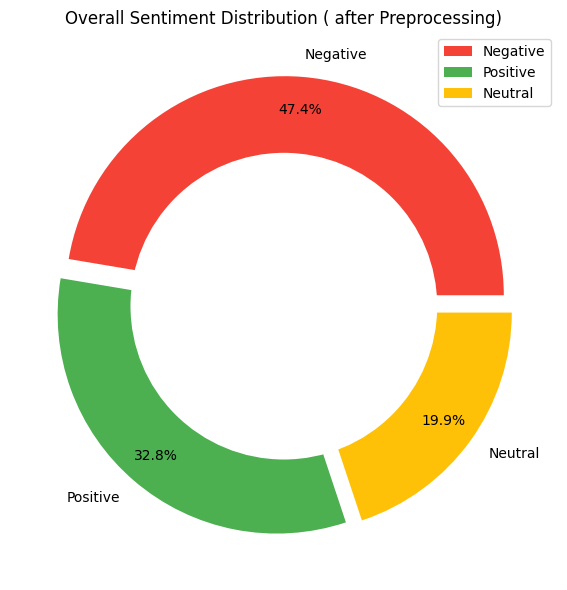

In [48]:

sentiment_counts = df["sentiment_label"].value_counts()

sizes = sentiment_counts.values
labels = sentiment_counts.index

color_map = {
    "Positive": "#4CAF50",
    "Negative": "#F44336",
    "Neutral": "#FFC107"
}
colors = [color_map[label] for label in labels]

explode = [0.05] * len(labels)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Sentiment Distribution ( after Preprocessing)")

plt.legend(labels, loc="upper right")

plt.tight_layout()
plt.show()

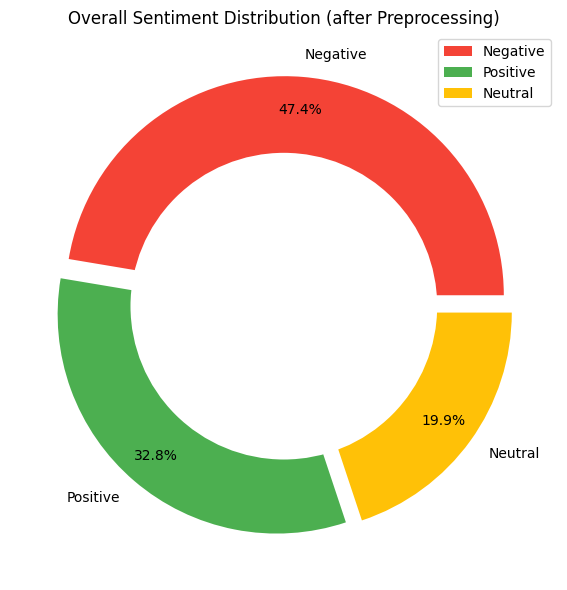

In [49]:
import matplotlib.pyplot as plt

# حساب عدد كل فئة
sentiment_counts = df["sentiment_label"].value_counts()

sizes = sentiment_counts.values
labels = sentiment_counts.index

# ربط كل فئة بلونها الصحيح
color_map = {
    "Positive": "#4CAF50",  # أخضر
    "Negative": "#F44336",  # أحمر
    "Neutral": "#FFC107"    # أصفر
}

# اختيار الألوان حسب الترتيب الفعلي
colors = [color_map[label] for label in labels]

explode = [0.05] * len(labels)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)


centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Sentiment Distribution (after Preprocessing)")

plt.legend(labels, loc="upper right")

plt.tight_layout()
plt.show()

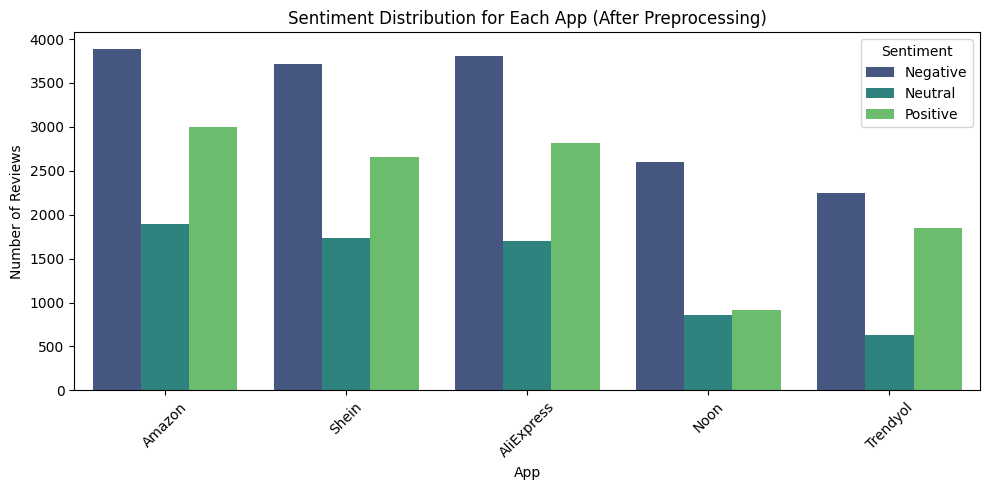

In [50]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [51]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Negative    16252
Positive    11243
Neutral      6825
Name: count, dtype: int64


In [52]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [53]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
!pip install gensim

In [55]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Negative    13002
Positive     8994
Neutral      5460
Name: count, dtype: int64
After SMOTE: sentiment_label
Negative    13002
Positive    13002
Neutral     13002
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

In [ ]:

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)


print("SVM Accuracy:", accuracy_score(y_test, y_pred_SVM))
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))


In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

# GaussianNB needs dense array
nb_model.fit(X_train_resampled.toarray(), y_train_resampled)

y_pred_nb = nb_model.predict(X_test.toarray())

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# Confusion Matrix Graph
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [ ]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)


print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_results = {
    "Algorithm": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": []
}

def add_results(name, y_true, y_pred):
    model_results["Algorithm"].append(name)
    model_results["Accuracy"].append(accuracy_score(y_true, y_pred))
    model_results["Precision"].append(precision_score(y_true, y_pred, average='macro'))
    model_results["Recall"].append(recall_score(y_true, y_pred, average='macro'))
    model_results["F1-score"].append(f1_score(y_true, y_pred, average='macro'))

add_results("Random Forest", y_test, rf_predictions)
add_results("Decision Tree", y_test, y_pred)
add_results("SVM", y_test, y_pred_SVM)
add_results("Naive Bayes", y_test, y_pred_nb)
add_results("XGBoost", y_test_encoded, y_pred_xgb)

results_df = pd.DataFrame(model_results)
results_df

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(model_results)

results_melted = results_df.melt(id_vars="Algorithm",
                                 var_name="Metric",
                                 value_name="Score")

plt.figure(figsize=(10,6))

sns.barplot(data=results_melted,
            x="Metric",
            y="Score",
            hue="Algorithm")

plt.title("Comparison of Algorithms using Bag of Words (BoW)")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

plt.ylim(0,1)

plt.legend(title="Algorithms")

plt.show()